# CutMix Augmentation 비교 실험
**Dataset**: Stanford Dogs | **Model**: ResNet-50 | **비교**: 기본 Augmentation vs 기본 + CutMix

## 1️⃣ Augmentation을 적용한 데이터셋 만들기

Stanford Dogs 데이터를 다운로드하고 기본 Augmentation이 적용된 DataLoader를 구성합니다.  
CutMix는 Dataset 단계가 아닌 **학습 루프 안(배치 단위)**에서 적용합니다.

In [1]:
import os, tarfile, urllib.request, random
import torch, torch.nn as nn, numpy as np
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torchvision.datasets import ImageFolder
from torchvision import models
from torch.utils.data import DataLoader, random_split

# ── 재현성 고정 ──────────────────────────────────────────────
def set_seed(seed=42):
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(42)
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 10
BATCH_SIZE = 64
LR         = 1e-3
print(f"device: {DEVICE} | torch: {torch.__version__} | numpy: {np.__version__}")

# ── 데이터 다운로드 ──────────────────────────────────────────
os.makedirs("./data_augmentation/data", exist_ok=True)
tar_path = "./data_augmentation/data/images.tar"

if not os.path.exists("./data_augmentation/data/Images"):
    print("이미지 다운로드 중... (~750MB)")
    urllib.request.urlretrieve(
        "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar", tar_path)
    print("압축 해제 중...")
    with tarfile.open(tar_path) as tar:
        tar.extractall("./data_augmentation/data")
    os.remove(tar_path)
    print("완료!")
else:
    print("이미 다운로드된 데이터가 있습니다.")

DATASET_DIR = "./data_augmentation/data/Images"

# ── Transform 정의 ───────────────────────────────────────────
# 훈련용: 랜덤 변환으로 다양성 증가 / 검증용: 크기만 맞추고 정규화
def get_transform(mode="no_aug"):
    if mode == "basic_aug":
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(p=0.5),   # 50% 확률 좌우 반전
            transforms.ColorJitter(brightness=0.2),   # 밝기 +-20% 변환
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])
    else:  # no_aug: 검증 시 왜곡 없이 성능 측정
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
        ])

# ── DataLoader 생성 ──────────────────────────────────────────
# 전체 데이터를 8:2 로 나눠 train / test 로 사용
def build_dataloaders(dataset_dir, batch_size=32, aug_mode="no_aug"):
    base_dataset = ImageFolder(dataset_dir, transform=None)
    train_size   = int(0.8 * len(base_dataset))
    test_size    = len(base_dataset) - train_size

    train_indices, test_indices = random_split(
        range(len(base_dataset)), [train_size, test_size])

    # 훈련셋: aug_mode 적용 / 테스트셋: 항상 no_aug
    train_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform(aug_mode)),
        train_indices.indices)
    test_dataset = torch.utils.data.Subset(
        ImageFolder(dataset_dir, transform=get_transform("no_aug")),
        test_indices.indices)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              shuffle=True,  num_workers=0, pin_memory=False)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size,
                              shuffle=False, num_workers=0, pin_memory=False)
    return train_loader, test_loader, base_dataset

train_loader, test_loader, base_dataset = build_dataloaders(
    DATASET_DIR, batch_size=BATCH_SIZE, aug_mode="basic_aug")

NUM_CLASSES = len(base_dataset.classes)
print(f"전체: {len(base_dataset)}장 | Train: {len(train_loader.dataset)}장 | Test: {len(test_loader.dataset)}장 | 클래스: {NUM_CLASSES}")
print('=3')

device: cuda | torch: 2.7.1+cu118 | numpy: 2.2.6
이미지 다운로드 중... (~750MB)
압축 해제 중...


/tmp/ipykernel_323/3400025428.py:31: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("./data_augmentation/data")


완료!
전체: 20580장 | Train: 16464장 | Test: 4116장 | 클래스: 120
=3


## 2️⃣ 모델 만들기

비교 실험을 위해 **동일한 구조의 ResNet-50** 두 개를 만듭니다.

### 🤔 Softmax를 명시하지 않는 이유
- 모델 출력은 **Logit** (raw 점수) 형태입니다.
- `nn.CrossEntropyLoss` = `LogSoftmax + NLLLoss` 를 **내부에서 자동 처리**합니다.
- 따라서 학습 중에는 Softmax 불필요 → 수치 안정성도 더 좋습니다.
- 추론 시 확률이 필요하면: `torch.softmax(model(x), dim=1)`

In [2]:
def build_resnet50(num_classes):
    """
    ImageNet 사전학습 ResNet-50 을 견종 분류기로 변환.
    Transfer Learning: backbone 가중치 유지, FC 레이어만 교체.
    Softmax 없는 이유: nn.CrossEntropyLoss 내부에서 LogSoftmax 자동 처리.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # 2048 -> num_classes
    return model.to(DEVICE)

# 동일 구조, 독립적으로 학습할 모델 두 개 생성
set_seed(42); model_basic  = build_resnet50(NUM_CLASSES)
set_seed(42); model_cutmix = build_resnet50(NUM_CLASSES)
print("model_basic  :", model_basic.fc)
print("model_cutmix :", model_cutmix.fc)
print("모델 두 개 생성 완료")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 189MB/s] 


model_basic  : Linear(in_features=2048, out_features=120, bias=True)
model_cutmix : Linear(in_features=2048, out_features=120, bias=True)
모델 두 개 생성 완료


## 3️⃣ 모델 훈련하기

### ⚠️ CutMix 사용 시 레이블의 변화
| 방식 | 레이블 형태 | 예시 |
|------|------------|------|
| 기본 Augmentation | **Hard label** (정수) | `3` |
| CutMix | **Soft label** (실수 벡터) | `[0, 0, 0.7, 0.3, ...]` |

CutMix는 두 이미지를 섞으므로 정답이 하나가 아닙니다.  
박스 면적 비율(λ)만큼 두 클래스에 확률을 나눠주는 Soft Label을 사용하고,  
`nn.CrossEntropyLoss`는 정수 레이블만 지원하므로 **Soft Label 전용 Loss를 직접 구현**합니다.

In [3]:
# ── CutMix 구현 ──────────────────────────────────────────────

def rand_bbox(size, lam):
    """잘라낼 박스 좌표 계산. 박스 크기 ∝ sqrt(1-lam)."""
    W, H = size[2], size[3]
    cut_rat      = np.sqrt(1.0 - lam)
    cut_w, cut_h = int(W * cut_rat), int(H * cut_rat)
    cx, cy       = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    return x1, y1, x2, y2

def cutmix_data(x, y, alpha=1.0, num_classes=120):
    """배치 단위 CutMix. 반환: (혼합 이미지, Soft Label)"""
    lam = np.random.beta(alpha, alpha)            # Beta 분포에서 λ 샘플링
    idx = torch.randperm(x.size(0)).to(x.device)  # 소스 이미지 인덱스 셔플

    x1, y1, x2, y2 = rand_bbox(x.size(), lam)
    mixed_x = x.clone()
    mixed_x[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]  # 박스 영역 교체

    # 실제 면적으로 λ 재계산 (클리핑으로 박스가 작아질 수 있음)
    lam = 1 - (x2 - x1) * (y2 - y1) / (x.size(-1) * x.size(-2))

    # Soft Label: 원본=0.7, 소스=0.3 식으로 혼합
    y_a = torch.zeros(x.size(0), num_classes, device=x.device).scatter_(1, y.view(-1,1), 1)
    y_b = torch.zeros(x.size(0), num_classes, device=x.device).scatter_(1, y[idx].view(-1,1), 1)
    return mixed_x, lam * y_a + (1 - lam) * y_b

def soft_cross_entropy(logits, soft_targets):
    """Soft Label용 Loss. 수식: -sum(soft_target * log_softmax(logit))"""
    log_prob = torch.nn.functional.log_softmax(logits, dim=1)
    return -(soft_targets * log_prob).sum(dim=1).mean()

# ── 학습 / 평가 함수 ──────────────────────────────────────────

def train_one_epoch(model, loader, optimizer, use_cutmix=False, num_classes=120):
    model.train()  # Dropout, BatchNorm 학습 모드
    total_loss, total_correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()  # 이전 배치 기울기 초기화
        if use_cutmix:
            images, soft_labels = cutmix_data(images, labels, num_classes=num_classes)
            logits      = model(images)
            loss        = soft_cross_entropy(logits, soft_labels)
            true_labels = soft_labels.argmax(dim=1)
        else:
            logits      = model(images)
            loss        = nn.CrossEntropyLoss()(logits, labels)
            true_labels = labels
        loss.backward(); optimizer.step()
        total_loss    += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == true_labels).sum().item()
        total         += images.size(0)
    return total_loss / total, total_correct / total

def evaluate(model, loader):
    model.eval()  # Dropout 비활성화, BatchNorm 추론 모드
    total_loss, total_correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():  # 기울기 계산 비활성화 → 메모리 절약
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            logits         = model(images)
            total_loss    += criterion(logits, labels).item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total         += images.size(0)
    return total_loss / total, total_correct / total

# ── 실험 1: 기본 Augmentation ─────────────────────────────────
print("\n" + "="*50 + "\n  실험 1: 기본 Augmentation\n" + "="*50)
set_seed(42)
opt1 = torch.optim.Adam(model_basic.parameters(),  lr=LR, weight_decay=1e-4)
sch1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=NUM_EPOCHS)
hist_basic = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = train_one_epoch(model_basic, train_loader, opt1, use_cutmix=False, num_classes=NUM_CLASSES)
    vl, va = evaluate(model_basic, test_loader); sch1.step()
    for k, v in zip(["train_loss","train_acc","val_loss","val_acc"], [tl,ta,vl,va]):
        hist_basic[k].append(v)
    print(f"Epoch [{epoch:>2}/{NUM_EPOCHS}]  Train Loss: {tl:.4f}  Acc: {ta:.4f}  |  Val Loss: {vl:.4f}  Acc: {va:.4f}")

# ── 실험 2: 기본 Augmentation + CutMix ───────────────────────
print("\n" + "="*50 + "\n  실험 2: 기본 Augmentation + CutMix\n" + "="*50)
set_seed(42)
opt2 = torch.optim.Adam(model_cutmix.parameters(), lr=LR, weight_decay=1e-4)
sch2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=NUM_EPOCHS)
hist_cutmix = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(1, NUM_EPOCHS + 1):
    tl, ta = train_one_epoch(model_cutmix, train_loader, opt2, use_cutmix=True, num_classes=NUM_CLASSES)
    vl, va = evaluate(model_cutmix, test_loader); sch2.step()
    for k, v in zip(["train_loss","train_acc","val_loss","val_acc"], [tl,ta,vl,va]):
        hist_cutmix[k].append(v)
    print(f"Epoch [{epoch:>2}/{NUM_EPOCHS}]  Train Loss: {tl:.4f}  Acc: {ta:.4f}  |  Val Loss: {vl:.4f}  Acc: {va:.4f}")


  실험 1: 기본 Augmentation
Epoch [ 1/10]  Train Loss: 1.9111  Acc: 0.4849  |  Val Loss: 1.6405  Acc: 0.5379
Epoch [ 2/10]  Train Loss: 1.1584  Acc: 0.6513  |  Val Loss: 1.7568  Acc: 0.5190
Epoch [ 3/10]  Train Loss: 0.8550  Acc: 0.7326  |  Val Loss: 1.4828  Acc: 0.5918
Epoch [ 4/10]  Train Loss: 0.6243  Acc: 0.7990  |  Val Loss: 1.2439  Acc: 0.6455
Epoch [ 5/10]  Train Loss: 0.4035  Acc: 0.8661  |  Val Loss: 1.2126  Acc: 0.6657
Epoch [ 6/10]  Train Loss: 0.2169  Acc: 0.9323  |  Val Loss: 0.9656  Acc: 0.7293
Epoch [ 7/10]  Train Loss: 0.1139  Acc: 0.9671  |  Val Loss: 0.9409  Acc: 0.7495
Epoch [ 8/10]  Train Loss: 0.0510  Acc: 0.9894  |  Val Loss: 0.8820  Acc: 0.7704
Epoch [ 9/10]  Train Loss: 0.0292  Acc: 0.9943  |  Val Loss: 0.8456  Acc: 0.7845
Epoch [10/10]  Train Loss: 0.0211  Acc: 0.9961  |  Val Loss: 0.8477  Acc: 0.7843

  실험 2: 기본 Augmentation + CutMix
Epoch [ 1/10]  Train Loss: 3.3753  Acc: 0.2945  |  Val Loss: 2.0388  Acc: 0.4563
Epoch [ 2/10]  Train Loss: 2.8310  Acc: 0.4240  | 

## 4️⃣ 훈련 과정 시각화

Train/Validation Loss & Accuracy 곡선을 에폭별로 비교합니다.

/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:16: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1011139993.py:17: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.savefig("./da

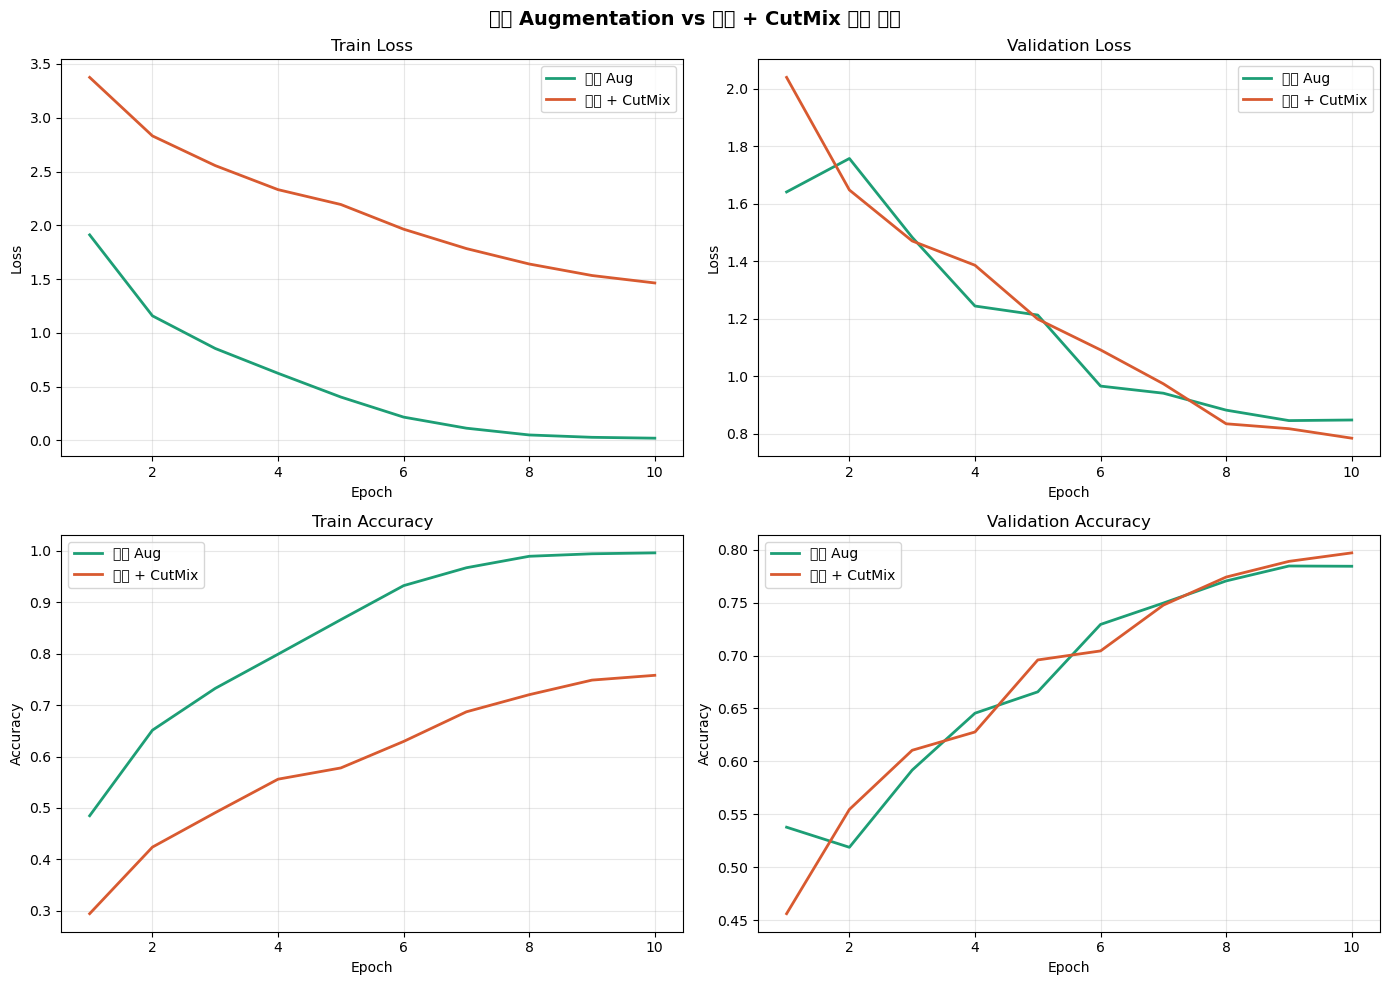

[저장됨] data_augmentation/cutmix_training_history.png


In [4]:
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("기본 Augmentation vs 기본 + CutMix 학습 과정", fontsize=14, fontweight="bold")

for ax, key, title, ylabel in [
    (axes[0,0], "train_loss", "Train Loss",           "Loss"),
    (axes[0,1], "val_loss",   "Validation Loss",      "Loss"),
    (axes[1,0], "train_acc",  "Train Accuracy",       "Accuracy"),
    (axes[1,1], "val_acc",    "Validation Accuracy",  "Accuracy"),
]:
    ax.plot(epochs, hist_basic[key],  color="#1D9E75", label="기본 Aug",      linewidth=2)
    ax.plot(epochs, hist_cutmix[key], color="#D85A30", label="기본 + CutMix", linewidth=2)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("./data_augmentation/cutmix_training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("[저장됨] data_augmentation/cutmix_training_history.png")

## 5️⃣ Augmentation에 의한 모델 성능 비교

최종 Validation Accuracy를 수치와 막대그래프로 비교합니다.


  방법                         Train Acc    Val Acc
  기본 Augmentation               0.9961     0.7843
  기본 + CutMix                   0.7580     0.7969

CutMix 적용 후 Val Acc 변화: +0.0126
→ CutMix 가 일반화 성능을 향상시켰습니다.


/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:25: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_323/1481931614.py:26: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.savefig("./data

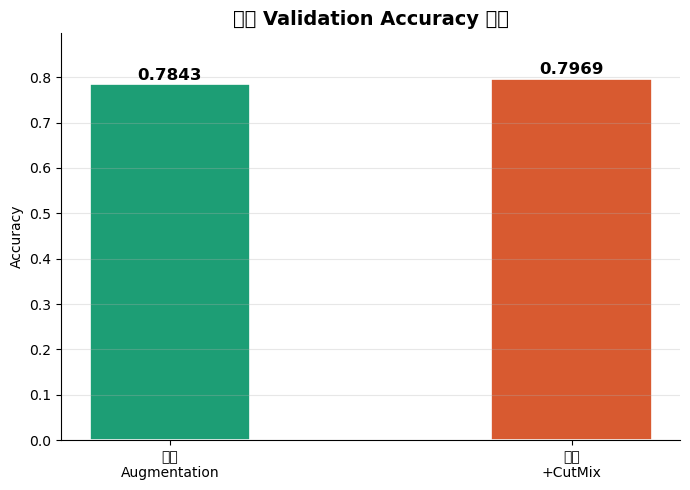

[저장됨] data_augmentation/cutmix_final_comparison.png


In [5]:
# ── 수치 비교 표 ──────────────────────────────────────────────
print("\n" + "="*52)
print(f"  {'방법':<25} {'Train Acc':>10} {'Val Acc':>10}")
print("="*52)
print(f"  {'기본 Augmentation':<25} {hist_basic['train_acc'][-1]:>10.4f} {hist_basic['val_acc'][-1]:>10.4f}")
print(f"  {'기본 + CutMix':<25} {hist_cutmix['train_acc'][-1]:>10.4f} {hist_cutmix['val_acc'][-1]:>10.4f}")
print("="*52)
diff = hist_cutmix['val_acc'][-1] - hist_basic['val_acc'][-1]
print(f"\nCutMix 적용 후 Val Acc 변화: {diff:+.4f}")
print("→ CutMix 가 일반화 성능을 향상시켰습니다." if diff > 0 else "→ 에폭 수를 늘리거나 alpha 값을 조정해 보세요.")

# ── 막대그래프 ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
val_accs = [hist_basic["val_acc"][-1], hist_cutmix["val_acc"][-1]]
bars = ax.bar(["기본\nAugmentation", "기본\n+CutMix"], val_accs,
              color=["#1D9E75", "#D85A30"], width=0.4, edgecolor="white", linewidth=1.2)
for bar, acc in zip(bars, val_accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{acc:.4f}", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("최종 Validation Accuracy 비교", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, min(1.0, max(val_accs) + 0.1))
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("./data_augmentation/cutmix_final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[저장됨] data_augmentation/cutmix_final_comparison.png")

# 회고

### 데이터 증강 기법이 반드시 높은 성능으로 직결되지 않는다는 것을 확인했다. 기본 방식과 CutMix를 비교해 보니 Validation Accuracy 차이가 1% 내외로 생각보다 미미했다. 하이퍼 파라미터나 다른 모델을 써 봄으로써 비교 분석이 필요할 것 같다. 지금의 결과는 CutMix 모델이 충분히 수렴하기에는 학습 횟수가 너무 부족했기 때문인 듯하다. 